In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("csv/serieHSlimpia.csv")
df.head()

,instante,HS10,HS20,HS30,HS40,HS50,HS60,TS30,TA,HA,litros_arbol
0,2020-03-01 00:00:00,0.6943,0.7429,0.7664,0.774,0.7801,0.7979,14.68,20.180,0.4929,62.181818
1,2020-03-01 00:09:00,0.6940,0.7429,0.7662,0.774,0.7799,0.7979,14.68,20.100,0.4977,62.181818
2,2020-03-01 00:18:00,0.6932,0.7429,0.7662,0.774,0.7800,0.7981,14.68,19.995,0.5042,62.181818
3,2020-03-01 00:27:00,0.6930,0.7426,0.7662,0.774,0.7799,0.7979,14.68,19.990,0.5121,62.181818
4,2020-03-01 00:36:00,0.6935,0.7429,0.7662,0.774,0.7799,0.7979,14.68,19.720,0.5260,62.181818


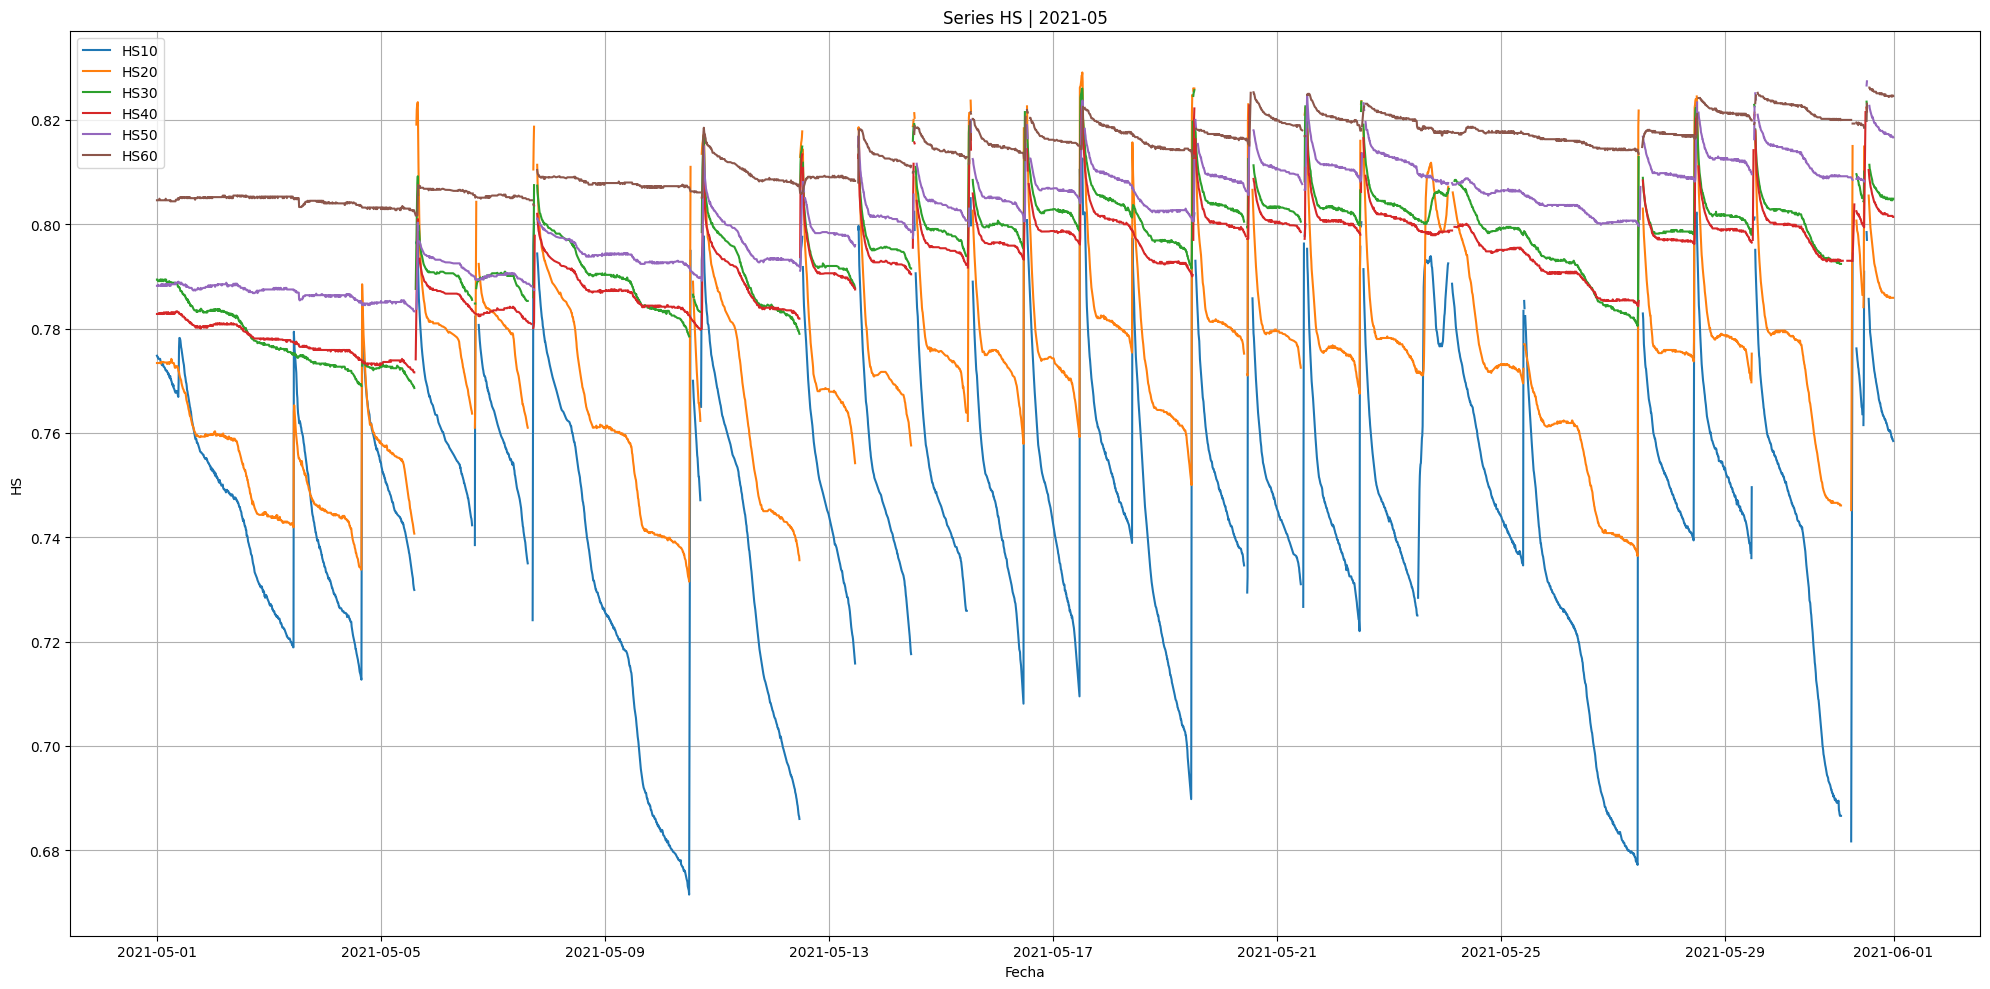

In [8]:
df["instante"] = pd.to_datetime(df["instante"])

YEAR = 2021
MONTH = 5

df_sel = df[
    (df["instante"].dt.year == YEAR) &
    (df["instante"].dt.month == MONTH)
]

hs_cols = df.filter(like="HS").columns

plt.figure(figsize=(20, 10))
for col in hs_cols:
    plt.plot(df_sel["instante"], df_sel[col], label=col)

plt.xlabel("Fecha")
plt.ylabel("HS")
plt.title(f"Series HS | {YEAR}-{MONTH:02d}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
dff = pd.read_csv("csv/LaClosaT.csv")
dff['instante'] = pd.to_datetime(dff['instante'])
dff = dff.set_index('instante')
dff = dff.drop(columns=['id_nodo', 'año'], errors='ignore') 
df_resampled = dff.resample('9min').mean()
df_resampled.head()


,HS10,HS20,HS30,HS40,HS50,HS60,TS30,TA,HA,litros_arbol
instante,,,,,,,,,,
2020-03-01 00:00:00,0.6943,0.7429,0.7664,0.774,0.7801,0.7979,14.68,20.180,0.4929,62.181818
2020-03-01 00:09:00,0.6940,0.7429,0.7662,0.774,0.7799,0.7979,14.68,20.100,0.4977,62.181818
2020-03-01 00:18:00,0.6932,0.7429,0.7662,0.774,0.7800,0.7981,14.68,19.995,0.5042,62.181818
2020-03-01 00:27:00,0.6930,0.7426,0.7662,0.774,0.7799,0.7979,14.68,19.990,0.5121,62.181818
2020-03-01 00:36:00,0.6935,0.7429,0.7662,0.774,0.7799,0.7979,14.68,19.720,0.5260,62.181818


In [6]:
df_imputed = pd.read_csv("csv/df_imputed.csv")
df_imputed["instante"] = pd.to_datetime(df_imputed["instante"])
df_imputed.head()

,instante,HS10,HS20,HS30,HS40,HS50,HS60,TS30,TA,HA,litros_arbol
0,2020-03-01 00:00:00,0.6943,0.7429,0.7664,0.774,0.7801,0.7979,14.68,20.180,0.4929,62.181818
1,2020-03-01 00:09:00,0.6940,0.7429,0.7662,0.774,0.7799,0.7979,14.68,20.100,0.4977,62.181818
2,2020-03-01 00:18:00,0.6932,0.7429,0.7662,0.774,0.7800,0.7981,14.68,19.995,0.5042,62.181818
3,2020-03-01 00:27:00,0.6930,0.7426,0.7662,0.774,0.7799,0.7979,14.68,19.990,0.5121,62.181818
4,2020-03-01 00:36:00,0.6935,0.7429,0.7662,0.774,0.7799,0.7979,14.68,19.720,0.5260,62.181818


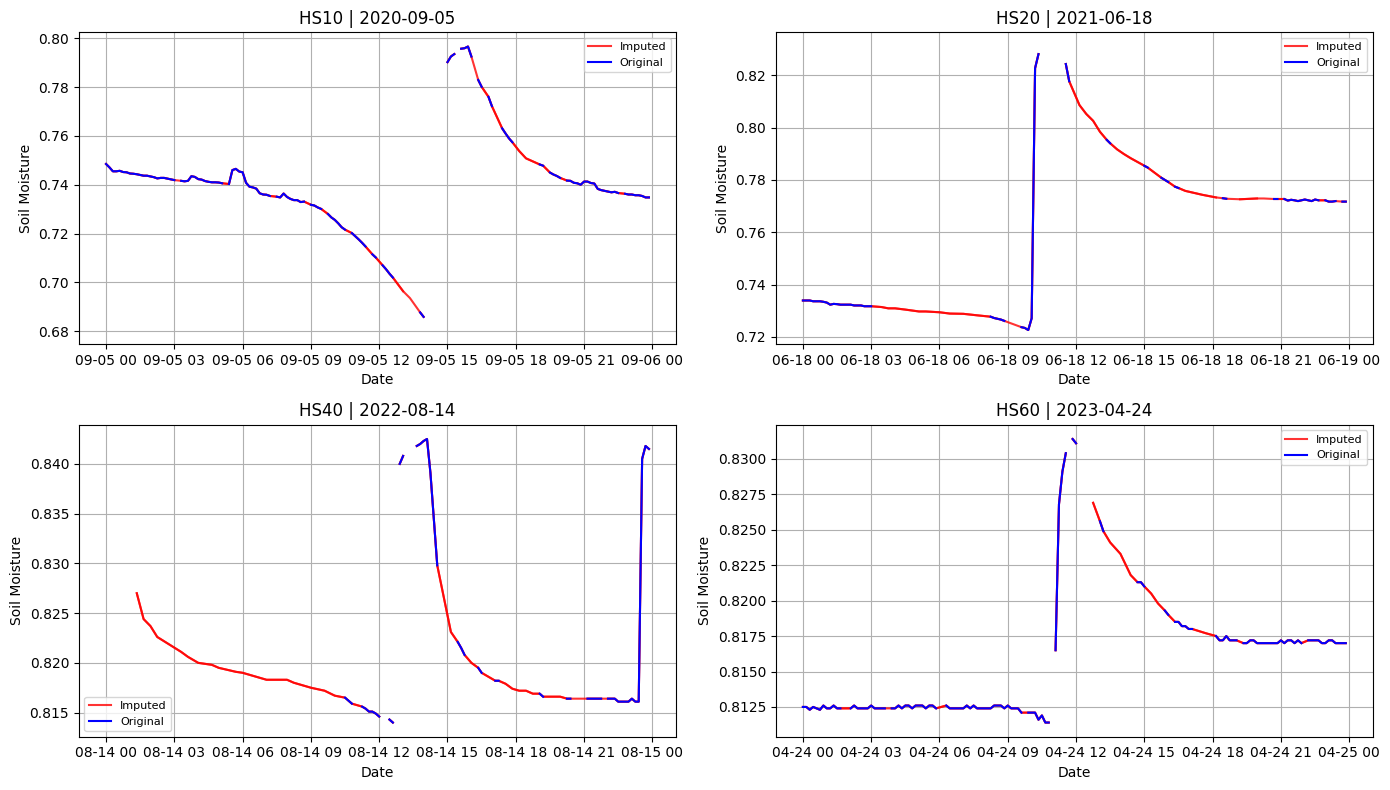

In [ ]:
import matplotlib.pyplot as plt

configs = [
    {"YEAR": 2020, "MONTH": 9, "DAY": 5, "HS_COL": "HS10"},
    {"YEAR": 2021, "MONTH": 6, "DAY": 18, "HS_COL": "HS20"},
    {"YEAR": 2022, "MONTH": 8, "DAY": 14, "HS_COL": "HS40"},
    {"YEAR": 2023, "MONTH": 4, "DAY": 24, "HS_COL": "HS60"},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, cfg in zip(axes, configs):

    YEAR = cfg["YEAR"]
    MONTH = cfg["MONTH"]
    DAY = cfg["DAY"]
    HS_COL = cfg["HS_COL"]

    df_day = df[
        (df["instante"].dt.year == YEAR) &
        (df["instante"].dt.month == MONTH) &
        (df["instante"].dt.day == DAY)
    ]

    df_im_day = df_imputed[
        (df_imputed["instante"].dt.year == YEAR) &
        (df_imputed["instante"].dt.month == MONTH) &
        (df_imputed["instante"].dt.day == DAY)
    ]

    df_res_day = df_resampled[
        (df_resampled.index.year == YEAR) &
        (df_resampled.index.month == MONTH) &
        (df_resampled.index.day == DAY)
    ]

    ax.plot(
    df_day["instante"],
    df_day[HS_COL],
    color="red",
    alpha=0.8,
    label="Imputed"
    )

    ax.plot(
        df_im_day["instante"],
        df_im_day[HS_COL],
        color="red",
        alpha=0.8
    )

    ax.plot(
        df_res_day.index,
        df_res_day[HS_COL],
        color="blue",
        label="Original"
    )

    ax.set_title(f"{HS_COL} | {YEAR}-{MONTH:02d}-{DAY:02d}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Soil Moisture")
    ax.grid(True)
    ax.legend(fontsize=8)

    plt.tight_layout()

plt.savefig(f"images/humedadimp.png", dpi=300, bbox_inches="tight")
plt.show()

# + Vars

In [ ]:
def interpolate_with_rules(series):
    s = series.copy()
    idxs = s.index

    isnull = s.isna()
    groups = []
    start = None

    for i in range(len(s)):
        if isnull.iloc[i] and start is None:
            start = i
        elif not isnull.iloc[i] and start is not None:
            groups.append((start, i - 1))
            start = None

    if start is not None:
        groups.append((start, len(s) - 1))

    for g0, g1 in groups:

        if g0 == 0 or g1 == len(s) - 1:
            continue

        prev_vals = s.iloc[:g0].dropna()
        if len(prev_vals) < 1:
            continue

        b = prev_vals.iloc[-1]
        b_time = prev_vals.index[-1]

        post_vals = s.iloc[g1+1:].dropna()
        if len(post_vals) < 1:
            continue

        d = post_vals.iloc[0]
        d_time = post_vals.index[0]

        if b == d:
            for i in range(g0, g1 + 1):
                s.iloc[i] = b
            continue

        if len(prev_vals) < 2 or len(post_vals) < 2:
            continue

        a = prev_vals.iloc[-2]      # penúltimo antes
        e = post_vals.iloc[1]       # segundo después

        increasing = (a < b < d < e)
        decreasing = (a > b > d > e)

        if not (increasing or decreasing):
            continue

        T = (d_time - b_time).total_seconds()
        if T <= 0:
            continue

        for i in range(g0, g1 + 1):
            t = (idxs[i] - b_time).total_seconds()
            s.iloc[i] = b + (d - b) * (t / T)

    return s

cols_extra = ["HA", "TA", "TS30", "litros_arbol"]

df_completo = df.copy()
df_completo = df_completo.set_index('instante')

for c in cols_extra:
    df_completo[c] = interpolate_with_rules(df_completo[c])


In [26]:
columns = [col for col in df_completo.columns]
nulos_por_var_año = df_completo.groupby(df_completo.index.year)[columns].apply(lambda x: x.isna().sum())

print("Número de valores nulos por variable y año (marzo-noviembre):")
print(nulos_por_var_año)

Número de valores nulos por variable y año (marzo-noviembre):
          HS10   HS20   HS30   HS40   HS50   HS60   TS30     TA     HA  \
instante                                                                 
2020      1552   6451   6404   6307   1327   1332   7655   8446  14324   
2021      3607  12306  12997  17145   8454   8634  19848  14503  24667   
2022      6608   6636   7047  16126  16121  16474  22423  17127  16738   
2023      1829   1900   2262   2327   2367   2474  13174   6499   6763   

          litros_arbol  
instante                
2020              5409  
2021             15641  
2022             19097  
2023             12491  
